In [1]:
# Welcome to your new notebook
# Type here in the cell editor to add code!
# =====================================================
# SmogNet
# Notebook: 04_Anomaly_Detection
# Isolation Forest + Rolling Z-score Hybrid
# =====================================================

from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler

import pandas as pd
import numpy as np

train=spark.sql(
"""
SELECT *
FROM Silver_training
"""
).toPandas()

test=spark.sql(
"""
SELECT *
FROM Silver_testing
"""
).toPandas()

print(train.shape)
print(test.shape)

StatementMeta(, 2a2ff0db-f4a1-4bc5-99fa-520bd5b18732, 3, Finished, Available, Finished, False)

(264335, 43)
(21792, 43)


In [2]:
def get_city(x):

    x=str(x).lower()

    if "lahore" in x:
        return "Lahore"

    elif "karachi" in x:
        return "Karachi"

    elif "islamabad" in x:
        return "Islamabad"

    elif "peshawar" in x:
        return "Peshawar"

    elif "quetta" in x:
        return "Quetta"

    return "Unknown"


for df in [train,test]:

    df["city"]=df[
        "source_file"
    ].apply(
        get_city
    )

print(
train["city"].value_counts()
)

StatementMeta(, 2a2ff0db-f4a1-4bc5-99fa-520bd5b18732, 4, Finished, Available, Finished, False)

city
Unknown      123134
Lahore        28269
Islamabad     28245
Peshawar      28245
Quetta        28221
Karachi       28221
Name: count, dtype: int64


In [3]:
# ==========================================
# Robust City + Season Baseline
# ==========================================

baseline=train.groupby(

["city","season"]

)[

"components_pm2_5"

].agg(

["median"]

).reset_index()

baseline.columns=[

"city",
"season",
"pm25_median"

]

print(baseline.head())

StatementMeta(, 2a2ff0db-f4a1-4bc5-99fa-520bd5b18732, 5, Finished, Available, Finished, False)

        city  season  pm25_median
0  Islamabad  Autumn      115.200
1  Islamabad  Spring       54.205
2  Islamabad  Summer       43.690
3  Islamabad  Winter      197.715
4    Karachi  Autumn       41.045


In [4]:
# ==========================================
# IQR by city + season
# ==========================================

iqr=train.groupby(

["city","season"]

)[

"components_pm2_5"

].quantile(
[0.25,0.75]
).unstack()

iqr.columns=[

"q25",
"q75"

]

iqr=iqr.reset_index()

iqr["iqr"]=(
iqr["q75"]
-
iqr["q25"]
)

iqr.head()

StatementMeta(, 2a2ff0db-f4a1-4bc5-99fa-520bd5b18732, 6, Finished, Available, Finished, False)

,city,season,q25,q75,iqr
0,Islamabad,Autumn,73.3925,182.470,109.0775
1,Islamabad,Spring,29.4875,95.275,65.7875
2,Islamabad,Summer,27.6600,64.500,36.8400
3,Islamabad,Winter,108.0675,332.125,224.0575
4,Karachi,Autumn,18.5050,97.395,78.8900


In [5]:
test=test.merge(

baseline,

on=[
"city",
"season"
],

how="left"

)

test=test.merge(

iqr,

on=[
"city",
"season"
],

how="left"

)

print(test.shape)

StatementMeta(, 2a2ff0db-f4a1-4bc5-99fa-520bd5b18732, 7, Finished, Available, Finished, False)

(21792, 48)


In [6]:
# ==========================================
# Rolling Median / IQR score
# ==========================================

test[
"robust_score"
]=np.abs(

(

test[
"components_pm2_5"
]

-

test[
"pm25_median"
]

)

/

(

test[
"iqr"
]+1

)

)

test[
"robust_score"
].describe()

StatementMeta(, 2a2ff0db-f4a1-4bc5-99fa-520bd5b18732, 8, Finished, Available, Finished, False)

count    21792.000000
mean         0.710482
std          1.132571
min          0.000000
25%          0.219305
50%          0.435331
75%          0.725167
max         26.298257
Name: robust_score, dtype: float64

In [7]:
features=[

"components_pm2_5",
"components_pm10",

"components_no",
"components_no2",

"components_o3",
"components_so2",

"components_nh3",
"components_co",

"temperature_2m",

"relative_humidity_2m",

"wind_speed_10m",

"PM10_PM25_ratio",

"NO2_NO_ratio",

"SO2_CO_ratio",

"severity_score",

"components_pm2_5_roll_mean",
"components_pm2_5_roll_std",

"components_pm10_roll_mean",
"components_pm10_roll_std",

"components_pm2_5_lag24",
"components_pm10_lag24"

]

StatementMeta(, 2a2ff0db-f4a1-4bc5-99fa-520bd5b18732, 9, Finished, Available, Finished, False)

In [8]:
for df in [train,test]:

    for c in features:

        df[c]=pd.to_numeric(
            df[c],
            errors="coerce"
        )

    df[features]=df[
        features
    ].fillna(0)

print("Numeric conversion complete")

StatementMeta(, 2a2ff0db-f4a1-4bc5-99fa-520bd5b18732, 10, Finished, Available, Finished, False)

Numeric conversion complete


In [9]:
scaler=StandardScaler()

X_train=scaler.fit_transform(train[features])

X_test=scaler.transform(test[features])

print(X_train.shape)

StatementMeta(, 2a2ff0db-f4a1-4bc5-99fa-520bd5b18732, 11, Finished, Available, Finished, False)

(264335, 21)


In [10]:
iso=IsolationForest(

n_estimators=200,

contamination=.03,

random_state=42

)

iso.fit(
X_train
)

print(
"Model trained"
)

StatementMeta(, 2a2ff0db-f4a1-4bc5-99fa-520bd5b18732, 12, Finished, Available, Finished, False)

Model trained


In [11]:
test[
"isolation_prediction"
]=iso.predict(
X_test
)

test[
"isolation_score"
]=iso.decision_function(
X_test
)

test[
[
"isolation_prediction",
"isolation_score"
]
].head()

StatementMeta(, 2a2ff0db-f4a1-4bc5-99fa-520bd5b18732, 13, Finished, Available, Finished, False)

,isolation_prediction,isolation_score
0,1,0.202405
1,1,0.182308
2,1,0.164309
3,1,0.194871
4,1,0.210755


In [12]:
test["zscore"]=np.abs(

(

test[
"components_pm2_5"
]

-

test[
"components_pm2_5_roll_mean"
]

)

/

(

test[
"components_pm2_5_roll_std"
]+0.001

)

)

test[
"zscore"
].head()

StatementMeta(, 2a2ff0db-f4a1-4bc5-99fa-520bd5b18732, 14, Finished, Available, Finished, False)

0    1.340078
1    1.277461
2    1.206218
3    1.124591
4    1.080858
Name: zscore, dtype: float64

In [14]:
# from sklearn.preprocessing import MinMaxScaler

# mms=MinMaxScaler()

# test[
# ["scaled_robust"]
# ]=mms.fit_transform(

# test[
# ["robust_score"]

# ]
# )

# test[
# "anomaly_score"
# ]=(

# 0.30*
# test["scaled_z"]

# +

# 0.30*
# (1-test["scaled_iso"])

# +

# 0.40*
# test["scaled_robust"]

# )

from sklearn.preprocessing import MinMaxScaler

mms=MinMaxScaler()

# Normalize Z-score

test[
["scaled_z"]
]=mms.fit_transform(

test[
["zscore"]

]
)

# Normalize Isolation score

test[
["scaled_iso"]
]=mms.fit_transform(

test[
["isolation_score"]

]
)

# Normalize robust score

test[
["scaled_robust"]
]=mms.fit_transform(

test[
["robust_score"]

]
)

print(
test[
[
"scaled_z",
"scaled_iso",
"scaled_robust"
]
].head()
)

StatementMeta(, 2a2ff0db-f4a1-4bc5-99fa-520bd5b18732, 17, Finished, Available, Finished, False)

   scaled_z  scaled_iso  scaled_robust
0  0.000027    0.904395       0.031725
1  0.000026    0.849179       0.032699
2  0.000024    0.799728       0.032679
3  0.000022    0.883695       0.031614
4  0.000022    0.927333       0.031534


In [15]:
test[
"anomaly_score"
]=(

0.6*

test[
"scaled_z"
]

+

0.4*

(

1-test[
"scaled_iso"
]

)

)

StatementMeta(, 2a2ff0db-f4a1-4bc5-99fa-520bd5b18732, 18, Finished, Available, Finished, False)

In [16]:
# # test[
# # "anomaly_flag"
# # ]=np.where(

# # test[
# # "anomaly_score"
# # ]>.70,

# # 1,

# # 0

# # )

# # print(

# # "Total anomalies:"

# # )

# # print(

# # test[
# # "anomaly_flag"
# # ].sum()

# # )

# # ======================================
# # Dynamic anomaly threshold
# # ======================================

# threshold = test[
#     "anomaly_score"
# ].quantile(0.95)

# print(
#     "Selected Threshold:",
#     threshold
# )

# test[
#     "anomaly_flag"
# ]=np.where(

#     test[
#         "anomaly_score"
#     ] > .55,

#     1,

#     0
# )

# print(
#     "Detected anomalies:"
# )

# print(
#     test[
#         "anomaly_flag"
#     ].sum()
# )
# Dynamic threshold instead of hardcoded threshold

threshold=np.percentile(
    test["anomaly_score"],
    95
)

print(
"Threshold:",
threshold
)

test["anomaly_flag"]=np.where(

    test["anomaly_score"]>=threshold,

    1,

    0
)

print(
"Total anomalies:"
)

print(
test["anomaly_flag"].sum()
)

StatementMeta(, 2a2ff0db-f4a1-4bc5-99fa-520bd5b18732, 19, Finished, Available, Finished, False)

Threshold: 0.18357260362246258
Total anomalies:
1090


In [22]:
# ==========================================
# Risk Level Creation
# ==========================================

conditions=[

    test["anomaly_score"]<0.30,

    test["anomaly_score"]<0.50,

    test["anomaly_score"]<0.70

]

choices=[

    "Low",

    "Moderate",

    "High"

]

test[
"risk_level"
]=np.select(

    conditions,

    choices,

    default="Critical"

)

print(
test[
"risk_level"
].value_counts()
)

StatementMeta(, 2a2ff0db-f4a1-4bc5-99fa-520bd5b18732, 27, Finished, Available, Finished, False)

risk_level
Low         21659
Moderate      111
High           22
Name: count, dtype: int64


In [23]:
# conditions=[

# test[
# "anomaly_score"
# ]<0.40,

# test[
# "anomaly_score"
# ]<0.60,

# test[
# "anomaly_score"
# ]<0.80

# ]
# conditions=[

# df["anomaly_score"]<0.30,

# df["anomaly_score"]<0.50,

# df["anomaly_score"]<0.70

# ]
# choices=[

# "Low",
# "Moderate",
# "High"

# ]

# test[
# "risk_level"
# ]=np.select(

# conditions,
# choices,

# default="Critical"

# )

# test[
# "risk_level"
# ].value_counts()

# ===================================
# Dynamic severity scoring
# ===================================

q1=df["anomaly_score"].quantile(.50)

q2=df["anomaly_score"].quantile(.80)

q3=df["anomaly_score"].quantile(.95)

print(q1,q2,q3)

conditions=[

df["anomaly_score"]<q1,

df["anomaly_score"]<q2,

df["anomaly_score"]<q3

]

choices=[

"Low",
"Moderate",
"High"

]

df["severity"]=np.select(

conditions,
choices,

default="Critical"

)

print(
df["severity"].value_counts()
)

StatementMeta(, 2a2ff0db-f4a1-4bc5-99fa-520bd5b18732, 28, Finished, Available, Finished, False)

0.06019351064503607 0.10240124236839031 0.18357260362246258
severity
Low         10896
Moderate     6537
High         3269
Critical     1090
Name: count, dtype: int64


StatementMeta(, 2a2ff0db-f4a1-4bc5-99fa-520bd5b18732, 29, Finished, Available, Finished, False)

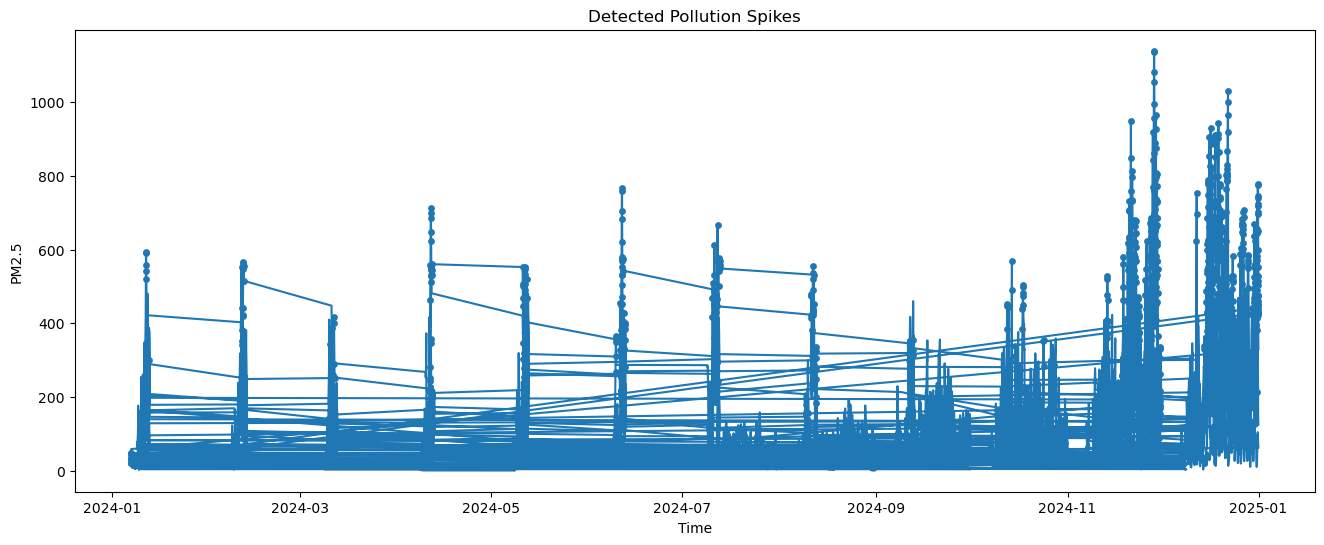

In [24]:
import matplotlib.pyplot as plt
plt.figure(
figsize=(16,6)
)

plt.plot(

test[
"parsed_datetime"
],

test[
"components_pm2_5"
]

)

plt.scatter(

test[
test[
"anomaly_flag"
]==1
][
"parsed_datetime"
],

test[
test[
"anomaly_flag"
]==1
][
"components_pm2_5"
],

s=15

)

plt.xlabel(
"Time"
)

plt.ylabel(
"PM2.5"
)

plt.title(
"Detected Pollution Spikes"
)

plt.show()

In [25]:
anomaly_output=test.copy()

print(
"Anomaly stage completed"
)

print(
anomaly_output.shape
)

StatementMeta(, 2a2ff0db-f4a1-4bc5-99fa-520bd5b18732, 31, Finished, Available, Finished, False)

Anomaly stage completed
(21792, 59)


In [26]:
anomaly_output[

[
"parsed_datetime",
"city",
"components_pm2_5",
"anomaly_score",
"anomaly_flag",
"risk_level"

]

].head(20)

StatementMeta(, 2a2ff0db-f4a1-4bc5-99fa-520bd5b18732, 32, Finished, Available, Finished, False)

,parsed_datetime,city,components_pm2_5,anomaly_score,anomaly_flag,risk_level
0,2024-08-17 00:00:00,Islamabad,12.12,0.038258,0,Low
1,2024-08-17 01:00:00,Islamabad,11.15,0.060344,0,Low
2,2024-08-17 02:00:00,Islamabad,11.17,0.080123,0,Low
3,2024-08-17 03:00:00,Islamabad,12.23,0.046535,0,Low
4,2024-08-17 04:00:00,Islamabad,12.31,0.029080,0,Low
5,2024-08-17 05:00:00,Islamabad,12.85,0.024821,0,Low
6,2024-08-17 06:00:00,Islamabad,16.62,0.026600,0,Low
7,2024-08-17 07:00:00,Islamabad,25.26,0.042569,0,Low
8,2024-08-17 08:00:00,Islamabad,34.15,0.056922,0,Low
9,2024-08-17 09:00:00,Islamabad,39.50,0.073394,0,Low


In [30]:
spark.createDataFrame(
anomaly_output
).write.mode(
"overwrite"
).format(
"delta"
).saveAsTable(
"Anomaly_output"
)

print(
"Temporary anomaly table saved"
)

StatementMeta(, 2a2ff0db-f4a1-4bc5-99fa-520bd5b18732, 36, Finished, Available, Finished, False)

Temporary anomaly table saved


In [31]:
test["anomaly_score"].describe()

StatementMeta(, 2a2ff0db-f4a1-4bc5-99fa-520bd5b18732, 37, Finished, Available, Finished, False)

count    21792.000000
mean         0.073582
std          0.056226
min          0.000002
25%          0.035850
50%          0.060194
75%          0.091884
max          0.696424
Name: anomaly_score, dtype: float64